Inventory Optimization

Inventory optimization is the process of managing stock efficiently to maintain optimal inventory levels while minimizing shortages, overstocking, and operational costs. In this project, inventory optimization is performed using sales quantity, revenue contribution, demand classification, and ABC analysis to identify high-value products and generate inventory restocking recommendations.


In simple :
managing stock efficiently

so that a business can:

- avoid stock shortages
- avoid overstocking
- reduce storage cost
- improve sales
- increase profit

A retail business has thousands of products.

- Some products:

   - sell very fast
   - generate high revenue

- while some:

   - sell slowly
   - stay in warehouse for long time

Inventory optimization helps identify:
- which products should be restocked, monitored, or reduced.

Problems Solved by Inventory Optimization:

| Problem      | Solution                       |
| ------------ | ------------------------------ |
| Stock-out    | reorder high-demand items      |
| Overstock    | reduce low-demand items        |
| Storage cost | optimize inventory levels      |
| Revenue loss | maintain fast-selling products |


in this project:
we will use:
- sales data, revenue, quantity sold, demand behavior

to analyze inventory. 

| Analysis               | Purpose                             |
| ---------------------- | ----------------------------------- |
| Top-selling products   | identify best-performing items      |
| ABC analysis           | classify products by business value |
| Demand classification  | identify high/medium/low demand     |
| Reorder recommendation | suggest inventory actions           |


| Category | Meaning               |
| -------- | --------------------- |
| A        | High-value products   |
| B        | Medium-value products |
| C        | Low-value products    |


| Product   | Revenue   | Category |
| --------- | --------- | -------- |
| Product A | Very High | A        |
| Product B | Medium    | B        |
| Product C | Low       | C        |


Dedmand Classification :
| Demand Level  | Meaning              |
| ------------- | -------------------- |
| High Demand   | sells frequently     |
| Medium Demand | average sales        |
| Low Demand    | slow-moving products |


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [19]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/cleaned_retail_data.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,Tuesday


In [20]:
# Product-level inventory summary

inventory = df.groupby(["StockCode", "Description"]).agg({
    "Quantity": "sum",
    "Revenue": "sum",
    "Invoice": "nunique"
}).reset_index()

inventory.columns = [
    "StockCode",
    "Description",
    "TotalQuantitySold",
    "TotalRevenue",
    "NumberOfOrders"
]

inventory.head()

,StockCode,Description,TotalQuantitySold,TotalRevenue,NumberOfOrders
0,10002,INFLATABLE POLITICAL GLOBE,8479,6638.27,297
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26
2,10109,BENDY COLOUR PENCILS,4,1.68,1
3,10120,DOGGY RUBBER,648,136.08,62
4,10123C,HEARTS WRAPPING TAPE,628,226.76,46


In [21]:
# Average quantity sold per order

inventory["AvgQuantityPerOrder"] = (
    inventory["TotalQuantitySold"] / inventory["NumberOfOrders"]
)

inventory.head()

,StockCode,Description,TotalQuantitySold,TotalRevenue,NumberOfOrders,AvgQuantityPerOrder
0,10002,INFLATABLE POLITICAL GLOBE,8479,6638.27,297,28.548822
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26,11.653846
2,10109,BENDY COLOUR PENCILS,4,1.68,1,4.000000
3,10120,DOGGY RUBBER,648,136.08,62,10.451613
4,10123C,HEARTS WRAPPING TAPE,628,226.76,46,13.652174


In [22]:
# Sort by revenue

inventory = inventory.sort_values(
    by="TotalRevenue",
    ascending=False
)

In [23]:
# ABC Analysis

inventory["RevenueShare"] = (
    inventory["TotalRevenue"] / inventory["TotalRevenue"].sum()
)

inventory["CumulativeRevenueShare"] = inventory["RevenueShare"].cumsum()

In [24]:
# Assign ABC category

def abc_category(value):
    if value <= 0.80:
        return "A"
    elif value <= 0.95:
        return "B"
    else:
        return "C"

inventory["ABC_Category"] = inventory["CumulativeRevenueShare"].apply(abc_category)

inventory.head()

,StockCode,Description,TotalQuantitySold,TotalRevenue,NumberOfOrders,AvgQuantityPerOrder,RevenueShare,CumulativeRevenueShare,ABC_Category
1862,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317,7.272837,0.016239,0.016239,A
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888,18.771890,0.014449,0.030687,A
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,80995.000000,0.009853,0.040540,A
4725,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612,28.416539,0.007855,0.048395,A
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,29.500000,0.007273,0.055668,A


In [25]:
# ABC category count

inventory["ABC_Category"].value_counts()

ABC_Category
C    2796
B    1365
A    1152
Name: count, dtype: int64

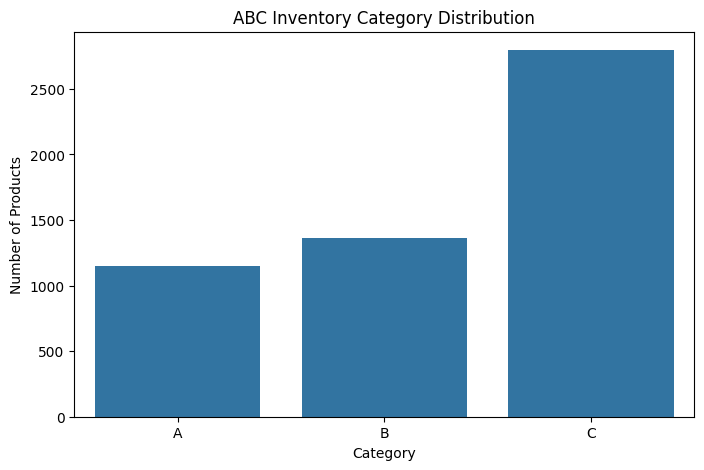

In [26]:
# Visualize ABC category count

plt.figure(figsize=(8,5))

sns.countplot(
    x="ABC_Category",
    data=inventory,
    order=["A", "B", "C"]
)

plt.title("ABC Inventory Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.savefig("../outputs/charts/inventory/abc_distribution.png")

plt.show()

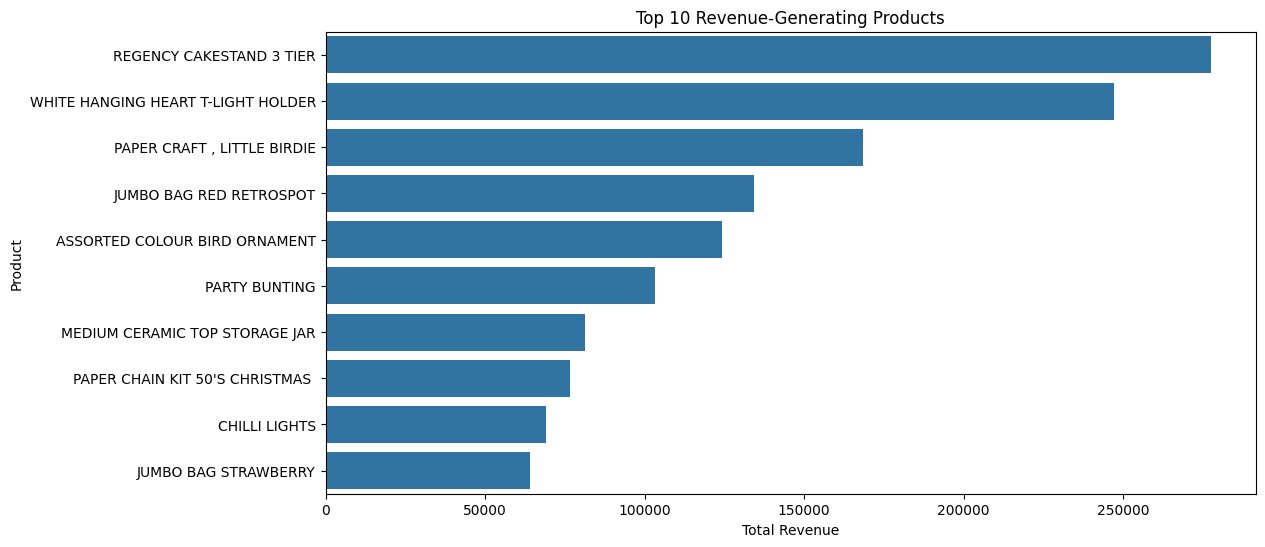

In [27]:
# Top 10 high-value products

top_inventory_products = inventory.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_inventory_products,
    x="TotalRevenue",
    y="Description"
)

plt.title("Top 10 Revenue-Generating Products")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.savefig("../outputs/charts/inventory/top_revenue_products.png")


plt.show()

In [28]:
# Demand classification using quantity sold

inventory["DemandLevel"] = pd.qcut(
    inventory["TotalQuantitySold"],
    q=3,
    labels=["Low Demand", "Medium Demand", "High Demand"]
)

inventory.head()

,StockCode,Description,TotalQuantitySold,TotalRevenue,NumberOfOrders,AvgQuantityPerOrder,RevenueShare,CumulativeRevenueShare,ABC_Category,DemandLevel
1862,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317,7.272837,0.016239,0.016239,A,High Demand
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888,18.771890,0.014449,0.030687,A,High Demand
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,80995.000000,0.009853,0.040540,A,High Demand
4725,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612,28.416539,0.007855,0.048395,A,High Demand
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,29.500000,0.007273,0.055668,A,High Demand


In [29]:
# Reorder recommendation logic

def reorder_recommendation(row):
    if row["ABC_Category"] == "A" and row["DemandLevel"] == "High Demand":
        return "High Priority Restock"
    elif row["ABC_Category"] in ["A", "B"] and row["DemandLevel"] in ["Medium Demand", "High Demand"]:
        return "Monitor Closely"
    elif row["ABC_Category"] == "C" and row["DemandLevel"] == "Low Demand":
        return "Low Priority / Avoid Overstock"
    else:
        return "Normal Stocking"

inventory["ReorderRecommendation"] = inventory.apply(
    reorder_recommendation,
    axis=1
)

# Cap extreme reorder quantities using 95th percentile

cap_value = inventory["AvgQuantityPerOrder"].quantile(0.95)

inventory["CappedAvgQuantityPerOrder"] = inventory["AvgQuantityPerOrder"].clip(
    upper=cap_value
)

inventory["EstimatedReorderQty"] = np.where(
    inventory["DemandLevel"] == "High Demand",
    inventory["CappedAvgQuantityPerOrder"] * 2,
    np.where(
        inventory["DemandLevel"] == "Medium Demand",
        inventory["CappedAvgQuantityPerOrder"] * 1.2,
        inventory["CappedAvgQuantityPerOrder"] * 0.5
    )
)

inventory["EstimatedReorderQty"] = (
    inventory["EstimatedReorderQty"]
    .round()
    .astype(int)
)



inventory.head()

,StockCode,Description,TotalQuantitySold,TotalRevenue,NumberOfOrders,AvgQuantityPerOrder,RevenueShare,CumulativeRevenueShare,ABC_Category,DemandLevel,ReorderRecommendation,CappedAvgQuantityPerOrder,EstimatedReorderQty
1862,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317,7.272837,0.016239,0.016239,A,High Demand,High Priority Restock,7.272837,15
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888,18.771890,0.014449,0.030687,A,High Demand,High Priority Restock,18.771890,38
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,80995.000000,0.009853,0.040540,A,High Demand,High Priority Restock,41.040289,82
4725,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612,28.416539,0.007855,0.048395,A,High Demand,High Priority Restock,28.416539,57
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,29.500000,0.007273,0.055668,A,High Demand,High Priority Restock,29.500000,59


In [30]:
# Recommendation summary

inventory["ReorderRecommendation"].value_counts()

ReorderRecommendation
Low Priority / Avoid Overstock    1692
Monitor Closely                   1484
Normal Stocking                   1185
High Priority Restock              952
Name: count, dtype: int64

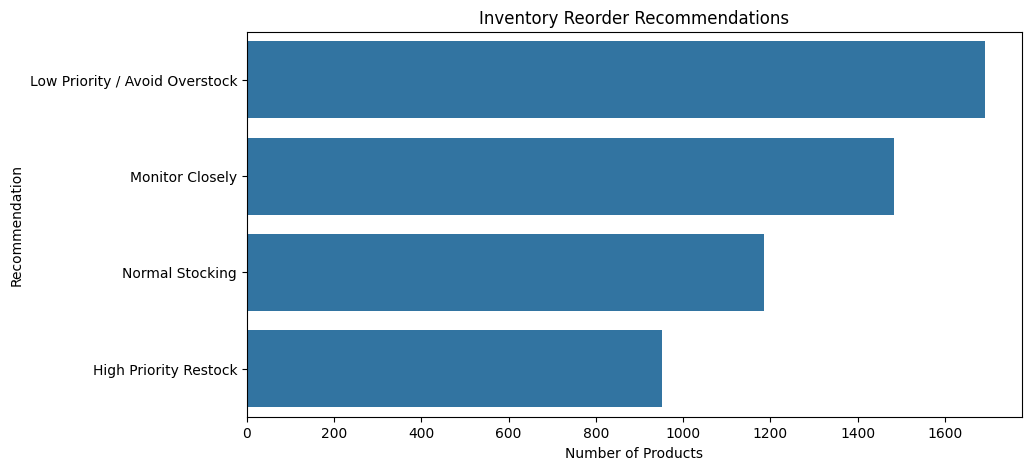

In [31]:
# Visualize reorder recommendation

plt.figure(figsize=(10,5))

sns.countplot(
    y="ReorderRecommendation",
    data=inventory,
    order=inventory["ReorderRecommendation"].value_counts().index
)

plt.title("Inventory Reorder Recommendations")
plt.xlabel("Number of Products")
plt.ylabel("Recommendation")

plt.savefig("../outputs/charts/inventory/reorder_recommendations.png")

plt.show()

In [32]:
# Products requiring high priority restock

high_priority_products = inventory[
    inventory["ReorderRecommendation"] == "High Priority Restock"
]

high_priority_products.head(10)

,StockCode,Description,TotalQuantitySold,TotalRevenue,NumberOfOrders,AvgQuantityPerOrder,RevenueShare,CumulativeRevenueShare,ABC_Category,DemandLevel,ReorderRecommendation,CappedAvgQuantityPerOrder,EstimatedReorderQty
1862,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317,7.272837,0.016239,0.016239,A,High Demand,High Priority Restock,7.272837,15
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888,18.771890,0.014449,0.030687,A,High Demand,High Priority Restock,18.771890,38
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,80995.000000,0.009853,0.040540,A,High Demand,High Priority Restock,41.040289,82
4725,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612,28.416539,0.007855,0.048395,A,High Demand,High Priority Restock,28.416539,57
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,29.500000,0.007273,0.055668,A,High Demand,High Priority Restock,29.500000,59
3627,47566,PARTY BUNTING,23460,103283.38,2077,11.295137,0.006041,0.061709,A,High Demand,High Priority Restock,11.295137,23
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,399.569231,0.004762,0.066470,A,High Demand,High Priority Restock,41.040289,82
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18,1691,16.782969,0.004480,0.070950,A,High Demand,High Priority Restock,16.782969,34
3931,79321,CHILLI LIGHTS,14843,69084.30,922,16.098698,0.004040,0.074990,A,High Demand,High Priority Restock,16.098698,32
4729,85099F,JUMBO BAG STRAWBERRY,35842,64127.77,1514,23.673712,0.003751,0.078741,A,High Demand,High Priority Restock,23.673712,47


In [33]:
# Save inventory optimization results

inventory.to_csv(
    "../outputs/inventory_optimization_results.csv",
    index=False
)

print("Inventory optimization results saved successfully!")

Inventory optimization results saved successfully!


Inventory Optimization Insight

Inventory optimization was performed using ABC analysis, demand classification, and reorder recommendation logic. Products were categorized based on their revenue contribution and sales demand to identify high-value inventory items.

Category A products generated the highest revenue and were identified as high-priority restock items due to strong sales demand. In contrast, Category C products contributed relatively low revenue and were marked as low-priority items to minimize overstocking risk.

The analysis revealed that a small number of products contributed significantly to overall revenue, while many low-demand products required careful inventory management. These insights can help businesses improve stock planning, reduce inventory costs, and maintain product availability for high-demand items.